# Visualizations


### Imports

In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
print("All libraries are working!")

All libraries are working!


In [2]:
#import cleaned data
df_cleaned = pd.read_csv('../data/processed_data/cleaned_player_data.csv')

### Plots

#### Player Profiles

player_label
casual       1806
churner     33523
hardcore     1938
Name: player_id, dtype: int64


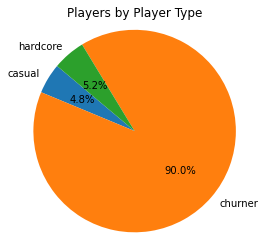

In [39]:
# Count of unique players by player label 
unique_players = df_cleaned.groupby('player_label')['player_id'].nunique()
print(unique_players)

#pie chart of unique players by player label
fig = plt.figure(figsize=(4, 4))
plt.pie(unique_players, labels=unique_players.index, autopct='%1.1f%%', startangle=140)
plt.title("Players by Player Type")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
#white background
fig.patch.set_facecolor('white')
plt.show()

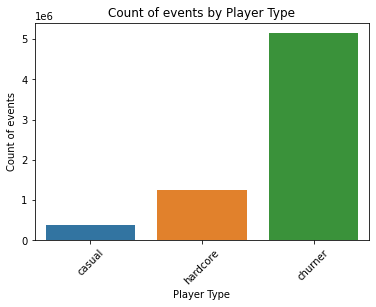

In [10]:
sns.countplot(data=df_cleaned, x='player_label')
plt.title("Count of events by Player Type")
plt.xlabel("Player Type")
plt.ylabel("Count of events")
plt.xticks(rotation=45)
plt.show()

**Sessions Per Player:**

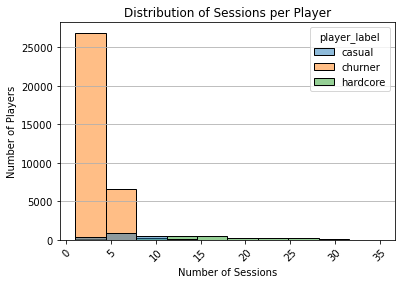

In [3]:
(
    df_cleaned
    .groupby(['player_label', 'player_id'])['session_id']
    .nunique()
    .reset_index(name='sessions_per_player')
    .pipe(lambda d: sns.histplot(data=d, x='sessions_per_player', hue='player_label', bins=10))
)
plt.title("Distribution of Sessions per Player")
plt.xlabel("Number of Sessions")
plt.ylabel("Number of Players")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

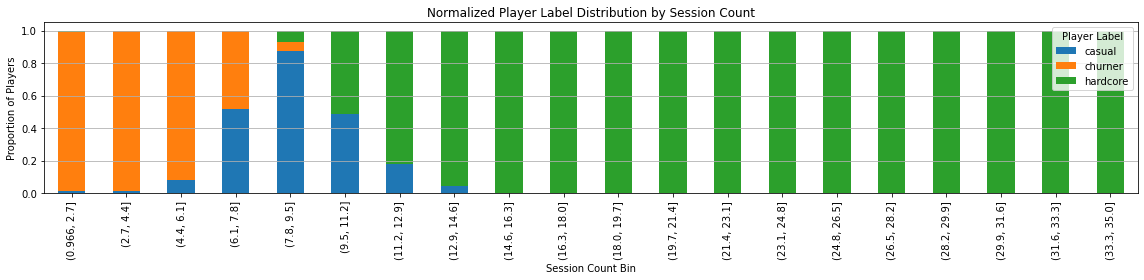

In [6]:

#stacked bar plot of sessions per player

sessions_per_player = (
    df_cleaned
    .groupby(['player_label', 'player_id'])['session_id']
    .nunique()
    .reset_index(name='sessions_per_player')
    .assign(player_label=lambda d: d['player_label'].astype('category')))

(
    sessions_per_player
    .assign(session_bin=lambda d: pd.cut(d['sessions_per_player'], bins=20))
    .groupby(['session_bin', 'player_label'])
    .size()
    .reset_index(name='count')
    .assign(proportion=lambda d: d['count'] / d.groupby('session_bin')['count'].transform('sum'))
    .pivot(index='session_bin', columns='player_label', values='proportion')
    .fillna(0)
    .plot(kind='bar', stacked=True, figsize=(16, 4))
)
plt.ylabel("Proportion of Players")
plt.xlabel("Session Count Bin")
plt.title("Normalized Player Label Distribution by Session Count")
plt.legend(title="Player Label")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [31]:
player_sessions = pd.DataFrame(
    df_cleaned
    .groupby(['player_id', 'session_id'])['session_length']
    .sum()
    .reset_index()
)

In [32]:
df_cleaned['session_length'] = pd.to_timedelta(df_cleaned['session_length'], errors='coerce')
player_sessions = (
    df_cleaned
    .groupby(['player_label','player_id', 'session_id'])['session_length']
    .first()
    .reset_index()
)
player_sessions['session_minutes'] = player_sessions['session_length'].dt.total_seconds() / 60
player_sessions.head()

,player_label,player_id,session_id,session_length,session_minutes
0,casual,002572e70fea4219a53102f415e04658,28a683b3ba934e98aaae775fbb0ee929,0 days 00:37:55.566383,37.926106
1,casual,002572e70fea4219a53102f415e04658,55f771d81c8548d5b3631d5871bac0ef,0 days 00:50:33.895013,50.564917
2,casual,002572e70fea4219a53102f415e04658,625b9f95aa814e5ea6246a856ab7ca17,0 days 00:52:30.412748,52.506879
3,casual,002572e70fea4219a53102f415e04658,70fcbff06633477e90a16f94eb288e82,0 days 01:58:33.155756,118.552596
4,casual,002572e70fea4219a53102f415e04658,7cdd6d49a9b9424194cc961dda4b2ed0,0 days 01:04:46.793547,64.779892


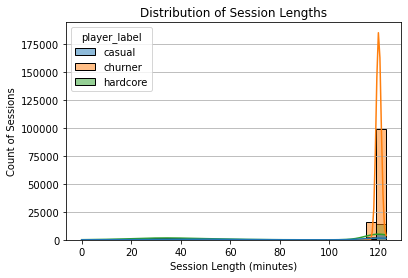

In [ ]:
#session length by player label
sns.histplot(data=player_sessions, x='session_minutes', hue='player_label', kde=True, bins=30)
plt.title("Distribution of Session Lengths")
plt.xlabel("Session Length (minutes)")
plt.ylabel("Count of Sessions")
plt.grid(axis='y')
plt.show()

In [40]:
# total minutes played per player by player label
total_minutes = (
    player_sessions
    .groupby(['player_label', 'player_id'])['session_minutes']
    .sum()
    .reset_index()
)
total_minutes.head()

,player_label,player_id,session_minutes
0,casual,002572e70fea4219a53102f415e04658,554.739600
1,casual,003b16cbe88b4f0ea482a3079335f2a9,529.278573
2,casual,003ed4a05eb0405dbf3a3d377312d957,883.002794
3,casual,0046d36507474cbe97020ce0d3b3ee32,926.788441
4,casual,005e784f80e9478fb1f357416fc03b67,221.894383


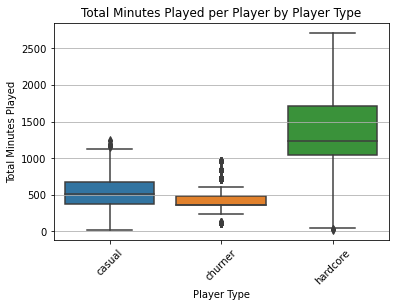

In [43]:
sns.boxplot(data=total_minutes, x='player_label', y='session_minutes')
plt.title("Total Minutes Played per Player by Player Type")
plt.xlabel("Player Type")
plt.ylabel("Total Minutes Played")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

<AxesSubplot:xlabel='session_minutes', ylabel='Count'>

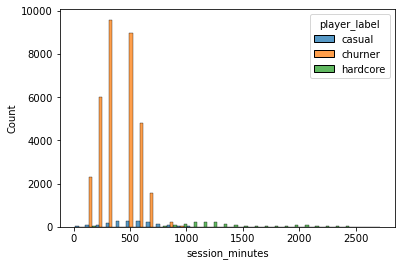

In [44]:
sns.histplot(data=total_minutes, x='session_minutes', hue='player_label', bins=30, multiple='dodge')

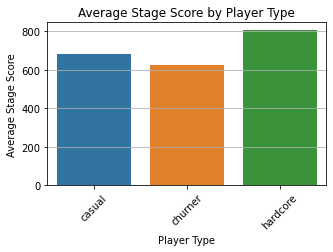

In [42]:
#stage score averages by player label
# Group by player_label and calculate the mean score for each stage
stage_score_means = df_cleaned.groupby('player_label')['stage_score'].mean().reset_index()
# Create a bar plot
plt.figure(figsize=(5, 3))
sns.barplot(data=stage_score_means, x='player_label', y='stage_score')
plt.title("Average Stage Score by Player Type")
plt.xlabel("Player Type")
plt.ylabel("Average Stage Score")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

#### Events Plots

Text(0, 0.5, 'Number of Events')

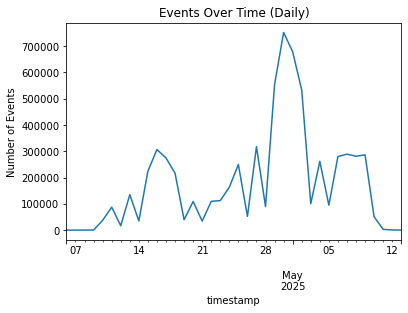

In [ ]:
#Events by day
df_cleaned.set_index('timestamp')['event_type'].resample('D').count().plot()
plt.title("Events Over Time (Daily)")
plt.ylabel("Number of Events")

Text(0, 0.5, 'Number of Events')

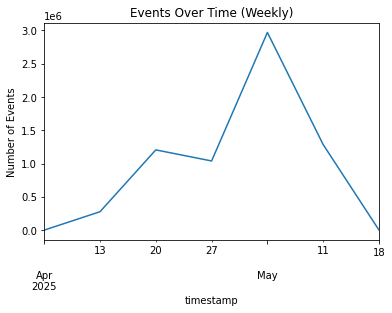

In [ ]:
# Events by Week
df_cleaned.set_index('timestamp')['event_type'].resample('W').count().plot()
plt.title("Events Over Time (Weekly)")
plt.ylabel("Number of Events")

Text(0.5, 0, 'Hour (0 = Midnight)')

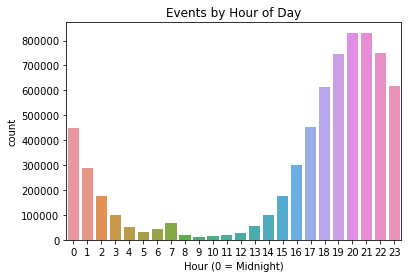

In [ ]:
order = list(range(0, 24))
df_cleaned['hour'] = df_cleaned['hour'].astype(int)
sns.countplot(data=df_cleaned, x='hour', order=order, )
plt.title("Events by Hour of Day")
plt.xlabel("Hour (0 = Midnight)")

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'Sunday'),
  Text(1, 0, 'Monday'),
  Text(2, 0, 'Tuesday'),
  Text(3, 0, 'Wednesday'),
  Text(4, 0, 'Thursday'),
  Text(5, 0, 'Friday'),
  Text(6, 0, 'Saturday')])

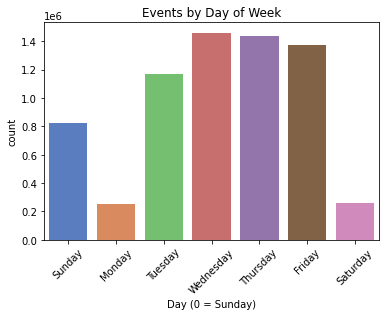

In [ ]:
# Events by day of week
order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
sns.countplot(data=df_cleaned, x='weekday', palette='muted', order=order)
plt.title("Events by Day of Week")
plt.xlabel("Day (0 = Sunday)")
plt.xticks(rotation=45)

event_type    BEGIN_SESSION  BEGIN_STAGE  END_SESSION  END_STAGE
player_label                                                    
casual             3.015009    46.984991     3.015009  46.984991
churner            2.223120    47.776880     2.223120  47.776880
hardcore           2.620671    47.379329     2.620671  47.379329


<Figure size 720x432 with 0 Axes>

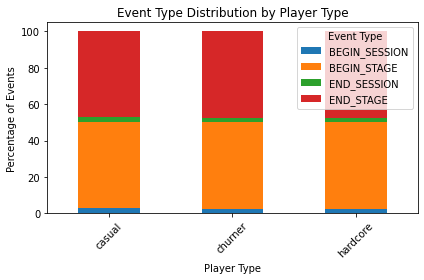

In [ ]:
# plot events by player label percentage  
event_type_by_player_label = df_cleaned.groupby('player_label')['event_type'].value_counts(normalize=True).unstack().fillna(0) * 100
print(event_type_by_player_label)
# Plot
plt.figure(figsize=(10, 6))
event_type_by_player_label.plot(kind='bar', stacked=True)
plt.title("Event Type Distribution by Player Type")
plt.xlabel("Player Type")
plt.ylabel("Percentage of Events")
plt.legend(title='Event Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print(event_type_counts)

               stage_score      week       day  events_per_session  \
player_label                                                         
casual        1.231394e+08   6855919   5212176            16331536   
churner       1.538553e+09  89686577  81246982           240509996   
hardcore      4.755664e+08  22363209  16611549            65204116   

              sessions_per_player  events_per_player  
player_label                                          
casual                    2849992           97395488  
churner                  20070232          911989604  
hardcore                 24181136          928724212  


#### Cohort Plots

In [ ]:
# cohort representation over time
df_cleaned['week'] = df_cleaned['timestamp'].dt.strftime('%U')
#make a catplot showing top 3 cohorts for each week of the month

weekly_counts = df_cleaned.groupby(['week', 'cohort_id'])['player_id'].count().reset_index()

weekly_counts.columns = ['week', 'cohort_id', 'event_count']

top3 = weekly_counts.sort_values(['week', 'event_count'], ascending=[True, False])
top3 = top3.groupby('week').head(3)


In [ ]:
top3 = top3.groupby(['week', 'cohort_id']).sum()

In [ ]:

sns.catplot(data=top3, kind='bar', x='week', y='event_count', hue='cohort_id')

#make a catplot showing top 3 cohorts for each day of the week 

#make a catplot showing top 3 cohorts for each hour of the day 


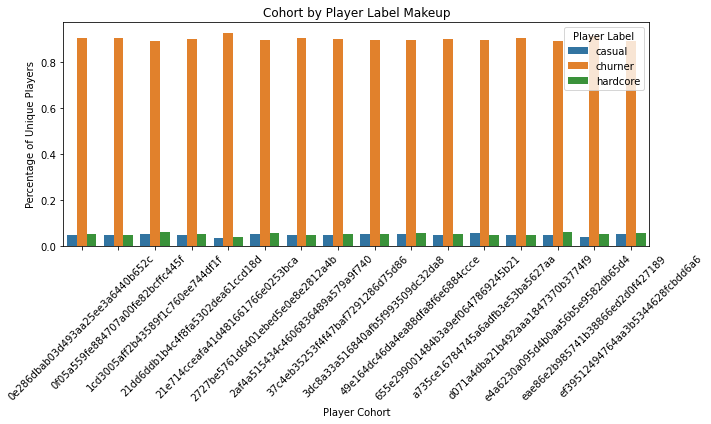

In [ ]:
# cohorts by player label makeup
# cohort by player label makeup
cohort_counts = df_cleaned.groupby(['player_cohort', 'player_label'])['player_id'].nunique().reset_index()
cohort_counts.columns = ['player_cohort', 'player_label', 'unique_players']
cohort_counts = cohort_counts.pivot(index='player_cohort', columns='player_label', values='unique_players')
cohort_counts = cohort_counts.fillna(0)
cohort_counts = cohort_counts.div(cohort_counts.sum(axis=1), axis=0)
cohort_counts = cohort_counts.reset_index()
cohort_counts = cohort_counts.melt(id_vars='player_cohort', var_name='player_label', value_name='percentage')
plt.figure(figsize=(10, 6))
sns.barplot(data=cohort_counts, x='player_cohort', y='percentage', hue='player_label')
plt.title("Cohort by Player Label Makeup")
plt.xlabel("Player Cohort")
plt.ylabel("Percentage of Unique Players")
plt.legend(title='Player Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Misc. Plots

In [ ]:
unique_players_by_type = df_cleaned.groupby('player_type')['player_id'].nunique()

In [ ]:
print(unique_players_by_type)

In [ ]:
unique_players_by_cohort = df_cleaned.groupby('cohort_id')['player_id'].nunique()


In [ ]:
#target label
print("Target label raw counts:\n", df_cleaned['player_type'].value_counts())
print("\nTarget label percentages:\n", df_cleaned['player_type'].value_counts(normalize=True))

In [ ]:
df_cleaned.columns

In [ ]:
# view player type by cohort
type_by_cohort = df_cleaned.groupby(['cohort_id', 'player_type'])['session_id'].count()


In [ ]:
type_by_cohort

In [ ]:
pivot = df_cleaned.pivot_table(
    index='cohort_id',
    columns='player_type',
    values='player_id',
    aggfunc='nunique',   # Or 'count' if each row = 1 player
    fill_value=0         # Optional: replace NaNs with 0s
)

In [ ]:
pivot